## 6.2 分面圖（Facet Grid）

### 1. 定義  
分面圖是透過 Facet Grid 技術，根據一個或多個分類變數將資料拆分成多個子圖，每個子圖單獨展示特定子群體的趨勢與分布，便於比較群體間的差異。


### 2. 範例圖表與說明  

（範例圖示：以性別分面，展示年齡與血糖值的散佈圖）

**觀察與解釋**：  
- 將資料依據性別分為兩個子圖，分別觀察男性與女性的年齡與血糖關係  
- 在男性子圖中，可能顯示出較明顯的正相關；女性子圖中分布較分散  
- 分面圖使得不同群體間的趨勢與變異更清晰


### 3. 適用情況  
- 探索各個分類群體內的變數關係  
- 比較不同群體（例如性別或區域）之間的差異  
- 避免單一圖表中因資料點過多而產生混亂


### 4. 優缺點  
- **優點**：  
  - 子圖分面展示，易於比較各群體的資料分布  
  - 避免因資料量大而重疊，圖形清晰  
- **缺點**：  
  - 分面數量過多可能導致排版困難  
  - 不同子圖的尺度可能需要標準化處理


### 5. 實際案例與圖表  
- **醫療領域**：依性別分面觀察年齡與血糖的關係  
- **電子商務**：依平台分面觀察用戶瀏覽與訂單量  
- **製造領域**：依班別展示設備使用率與維修次數


### 6. 實作範例：醫學領域 - 依性別比較年齡與血糖關係（Facet Grid）

#### 資料說明  
模擬 200 筆病患資料，包含以下欄位：  
- **Age**：年齡（整數，20～80 歲）  
- **BMI**：身體質量指數（浮點數，平均約 24）  
- **Blood_Sugar**：血糖值（根據年齡與 BMI 模擬生成）  
- **Gender**：性別（"Male" 或 "Female"）

📥 可使用先前下載之資料集：`patient_bubble_data.csv`，並加入 `Blood_Sugar` 欄位


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH6_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH6_dataset/images'

Mounted at /content/drive


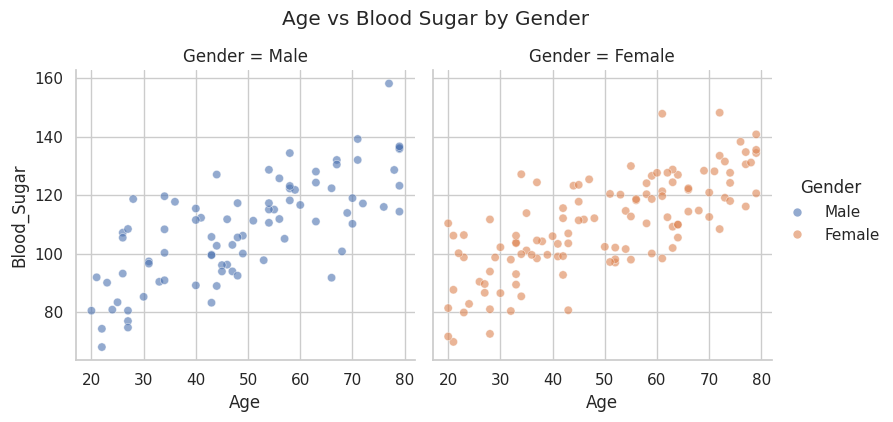

In [3]:
# 匯入必要套件
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 讀取先前模擬的病患資料集
data_file = "patient_bubble_data.csv"
df = pd.read_csv(path+"/"+data_file)

# 固定隨機種子以確保結果一致
np.random.seed(42)

# 依據 Age 與 BMI 模擬生成 Blood_Sugar 數值，加上隨機誤差
# 模擬公式：基礎值 70 + 年齡影響 + BMI 偏差 + 隨機誤差
df["Blood_Sugar"] = (
    70 +
    0.8 * df["Age"] +
    (df["BMI"] - 24) * 2 +
    np.random.normal(0, 10, size=len(df))
)

# 設定 Seaborn 圖表樣式
sns.set(style="whitegrid")

# 使用 relplot 建立 Facet Grid，依性別分面觀察年齡與血糖關係
g = sns.relplot(
    data=df,
    x="Age",                 # X 軸：年齡
    y="Blood_Sugar",         # Y 軸：血糖值
    col="Gender",            # 分面條件：性別
    hue="Gender",            # 色彩群組：性別
    kind="scatter",          # 散佈圖
    height=4,                # 每張子圖高度
    aspect=1,                # 子圖寬高比例
    alpha=0.6,               # 設定透明度
    marker="o"               # 使用實心圓形
)

# 加入主標題並適度調整位置
g.fig.suptitle("Age vs Blood Sugar by Gender", y=1.05)

# 顯示圖表
plt.show()


#### Try it! 6. 實作範例：
改變分面方向與配色，比較閱讀效果的差異。

**程式要求**
1. 讀取 `datasets/health_pairplot_data.csv`。
2. 使用 `sns.relplot` 繪製散佈圖，改用 `row='Gender'` 讓子圖上下排列。
3. 指定 `palette='Set2'`，並調整 `height` 與 `aspect` 讓橫向子圖比例適中。

#### 📌 補充參數與設定說明

| 參數      | 說明                                    | 建議範例值                |
|-----------|-----------------------------------------|---------------------------|
| `col`     | 指定用來分面（橫向）的分類變數             | `"Gender"`                |
| `hue`     | 分組著色變數                             | `"Gender"`                |
| `kind`    | 圖形類型（散佈圖或折線圖）                 | `"scatter"`, `"line"`     |
| `height`  | 每個子圖的高度（單位為英吋）              | `4`, `5`                  |
| `aspect`  | 子圖寬高比例                              | `1`, `1.2`, `1.5`         |
